# Compare Models: Reconstruction Errors and MST Metrics
Load summary JSON outputs created by notebook 11 and compare models.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [2]:
project_root = Path.cwd().resolve().parent
results_root = project_root / "results"

DATASET_NAME = "data_00_20_w724_s10"
DATASET = 'test'  # 'train', 'val', 'test' or 'all'
dataset_dir = results_root / DATASET_NAME
analysis_dir = dataset_dir / f"reconstruction_analysis_{DATASET}"
comparison_dir = dataset_dir / f"comparison_{DATASET}"
comparison_dir.mkdir(parents=True, exist_ok=True)

if not dataset_dir.exists():
    available = [p.name for p in results_root.iterdir() if p.is_dir()]
    raise FileNotFoundError(f"Dataset not found: {dataset_dir}. Available: {available}")

if not analysis_dir.exists():
    raise FileNotFoundError(f"Missing reconstruction_analysis folder: {analysis_dir}")

model_dirs = sorted([p for p in analysis_dir.iterdir() if p.is_dir()])
model_names = [p.name for p in model_dirs]

print(f"Models found ({len(model_names)}): {model_names}")

Models found (16): ['AE_100dim_0004', 'AE_10dim_0003', 'AE_20dim_0008', 'AE_288dim_0004', 'AE_3dim_0002', 'linearAE_100dim_0002', 'linearAE_10dim_0002', 'linearAE_20dim_0002', 'linearAE_288dim_0003', 'linearAE_3dim_0004', 'PCA_100dim', 'PCA_10dim', 'PCA_20dim', 'PCA_288dim', 'PCA_3dim', 'VAE_3dim_0002']


In [3]:
import re


def load_json(path: Path):
    with open(path, "r") as f:
        return json.load(f)


def flatten_metric_stats(metrics_dict, prefix=""):
    flat = {}
    for metric, stats in metrics_dict.items():
        for stat, val in stats.items():
            key = f"{prefix}{metric}_{stat}"
            flat[key] = val
    return flat


def load_model_stats(model_dir: Path):
    records = []

    errors_path = model_dir / f"reconstruction_errors_{DATASET}.json"
    if errors_path.exists():
        payload = load_json(errors_path)

        if isinstance(payload, dict):
            record = {"model": model_dir.name}
            errors_block = payload.get("reconstruction_errors")
            mst_block = payload.get("mst_metrics")

            if errors_block is None and "MSE" in payload:
                errors_block = payload

            if errors_block is not None:
                record.update(flatten_metric_stats(errors_block, prefix="err_"))
            else:
                print(f"Missing reconstruction_errors block for {model_dir.name}")

            if mst_block is not None:
                record.update(flatten_metric_stats(mst_block, prefix="mst_"))
            else:
                print(f"Missing mst_metrics block for {model_dir.name}")

            records.append(record)
        elif isinstance(payload, list):
            if payload:
                sweep_df = pd.DataFrame(payload)
                for _, row in sweep_df.iterrows():
                    k = None
                    if "n_components" in row and pd.notna(row["n_components"]):
                        k = int(row["n_components"])

                    model_name = f"{model_dir.name}_{k}" if k is not None else model_dir.name
                    record = {"model": model_name}

                    err_block = None
                    row_errs = row.get("reconstruction_errors")
                    if isinstance(row_errs, dict):
                        err_block = row_errs
                    else:
                        err_block = {}
                        if "MSE_mean" in row and pd.notna(row["MSE_mean"]):
                            err_block.setdefault("MSE", {})["mean"] = float(row["MSE_mean"])
                        if "MAE_mean" in row and pd.notna(row["MAE_mean"]):
                            err_block.setdefault("MAE", {})["mean"] = float(row["MAE_mean"])
                        if "Frobenius_mean" in row and pd.notna(row["Frobenius_mean"]):
                            err_block.setdefault("Frobenius", {})["mean"] = float(row["Frobenius_mean"])
                        if not err_block:
                            err_block = None

                    if err_block is not None:
                        record.update(flatten_metric_stats(err_block, prefix="err_"))
                    else:
                        print(f"Missing reconstruction_errors block for {model_name}")

                    if "mean_explained_variance" in row and pd.notna(row["mean_explained_variance"]):
                        record["pca_mean_explained_variance"] = float(row["mean_explained_variance"])
                    if k is not None:
                        record["pca_selected_k"] = k

                    records.append(record)
            else:
                print(f"Empty reconstruction_errors list for {model_dir.name}")
        else:
            print(f"Unexpected reconstruction_errors format for {model_dir.name}")
    else:
        print(f"Missing reconstruction_errors.json for {model_dir.name}")

    return records


def parse_model_name(model_name: str):
    method_raw = model_name.split("_")[0]
    method_map = {"pca": "PCA", "linearae": "linearAE", "ae": "AE"}
    method = method_map.get(method_raw.lower(), method_raw)

    if method == "linearAE" and "biasfalse" in model_name.lower():
        method = "linearAE_biasFalse"
    if method == "AE" and "relu" in model_name.lower():
        method = "AE_ReLU"

    k = None
    dim_match = re.search(r"(\d+)\s*dim", model_name, flags=re.IGNORECASE)
    if dim_match:
        k = int(dim_match.group(1))
    else:
        after_method = re.search(r"^[^_]+_(\d+)(?:_|$)", model_name)
        if after_method:
            k = int(after_method.group(1))
        else:
            any_num = re.search(r"(\d+)", model_name)
            if any_num:
                k = int(any_num.group(1))

    return method, k


def extract_run_id(model_name: str, k):
    nums = [int(x) for x in re.findall(r"(\d+)", model_name)]
    if not nums:
        return None
    if k is None:
        return nums[-1]
    for value in reversed(nums):
        if value != k:
            return value
    return None


method_order = ["PCA", "linearAE_biasFalse", "linearAE", "AE", "AE_ReLU"]
method_rank = {m: i for i, m in enumerate(method_order)}


def model_sort_key(model_name: str):
    method, k = parse_model_name(model_name)
    run_id = extract_run_id(model_name, k)
    method_pos = method_rank.get(method, len(method_order))
    k_pos = k if k is not None else float("inf")
    run_pos = run_id if run_id is not None else float("inf")
    return (method_pos, k_pos, run_pos, model_name.lower())


def sort_by_method_k(df: pd.DataFrame):
    ordered_index = sorted(df.index, key=model_sort_key)
    return df.loc[ordered_index]


print(model_dirs)
records_nested = [load_model_stats(p) for p in model_dirs]
records = [record for sublist in records_nested for record in sublist]
stats_df = pd.DataFrame(records).set_index("model").sort_index()
stats_df = sort_by_method_k(stats_df)
stats_df

[WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis_test/AE_100dim_0004'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis_test/AE_10dim_0003'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis_test/AE_20dim_0008'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis_test/AE_288dim_0004'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis_test/AE_3dim_0002'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis_test/linearAE_100dim_0002'), WindowsPath('C:/Users/dylan/Desktop/T

,err_MSE_mean,err_MSE_std,err_MSE_min,err_MSE_median,err_MSE_max,err_MAE_mean,err_MAE_std,err_MAE_min,err_MAE_median,err_MAE_max,err_Frobenius_mean,err_Frobenius_std,err_Frobenius_min,err_Frobenius_median,err_Frobenius_max,mst_edge_overlap_pct_count,mst_edge_overlap_pct_mean,mst_edge_overlap_pct_std,mst_edge_overlap_pct_min,mst_edge_overlap_pct_25%,mst_edge_overlap_pct_50%,mst_edge_overlap_pct_75%,mst_edge_overlap_pct_max,mst_edge_jaccard_pct_count,mst_edge_jaccard_pct_mean,...,mst_avg_path_len_unweighted_max,mst_avg_path_len_unweighted_recon_count,mst_avg_path_len_unweighted_recon_mean,mst_avg_path_len_unweighted_recon_std,mst_avg_path_len_unweighted_recon_min,mst_avg_path_len_unweighted_recon_25%,mst_avg_path_len_unweighted_recon_50%,mst_avg_path_len_unweighted_recon_75%,mst_avg_path_len_unweighted_recon_max,mst_avg_path_len_unweighted_diff_count,mst_avg_path_len_unweighted_diff_mean,mst_avg_path_len_unweighted_diff_std,mst_avg_path_len_unweighted_diff_min,mst_avg_path_len_unweighted_diff_25%,mst_avg_path_len_unweighted_diff_50%,mst_avg_path_len_unweighted_diff_75%,mst_avg_path_len_unweighted_diff_max,mst_betweenness_topk_overlap_pct_count,mst_betweenness_topk_overlap_pct_mean,mst_betweenness_topk_overlap_pct_std,mst_betweenness_topk_overlap_pct_min,mst_betweenness_topk_overlap_pct_25%,mst_betweenness_topk_overlap_pct_50%,mst_betweenness_topk_overlap_pct_75%,mst_betweenness_topk_overlap_pct_max
model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
PCA_3dim,0.002401,0.001506,0.000653,0.002057,0.006669,0.036248,0.011834,0.018974,0.034880,0.063974,16.966560,5.233901,9.252765,16.417511,29.561813,42.0,53.231764,7.968543,38.227147,46.537396,52.354571,58.795014,69.806094,42.0,36.665565,...,12.760426,42.0,10.110092,1.020756,7.011386,9.479354,10.034343,10.752395,11.905725,42.0,1.171304,0.860616,0.054300,0.384269,1.190661,1.716686,3.324207,42.0,36.904762,14.564925,10.0,30.0,30.0,50.0,60.0
PCA_10dim,0.000370,0.000204,0.000105,0.000314,0.001212,0.014059,0.003942,0.007596,0.013635,0.026499,6.736960,1.775917,3.716514,6.414659,12.604712,42.0,76.447698,6.254977,60.941828,73.060942,77.285319,81.301939,86.980609,42.0,62.272212,...,12.760426,42.0,10.031163,1.287661,8.175219,8.958640,10.170636,10.663029,13.606771,42.0,0.744742,0.748693,0.010285,0.157554,0.523423,0.973428,3.649929,42.0,60.952381,19.607057,10.0,50.0,60.0,77.5,100.0
PCA_20dim,0.000178,0.000111,0.000061,0.000158,0.000572,0.009604,0.002906,0.005530,0.009538,0.017338,4.646162,1.348226,2.830456,4.548124,8.654916,42.0,82.027437,4.849219,66.481994,78.393352,82.271468,86.080332,90.581717,42.0,69.804579,...,12.760426,42.0,9.960438,1.168552,8.207129,9.257002,9.951592,10.356346,12.960025,42.0,0.770595,0.631949,0.038322,0.264581,0.625702,1.059614,2.614484,42.0,71.428571,16.165520,40.0,60.0,70.0,80.0,100.0
PCA_100dim,0.000048,0.000044,0.000005,0.000044,0.000271,0.004751,0.001893,0.001684,0.004789,0.011649,2.322813,0.956504,0.822105,2.395833,5.954099,42.0,89.671547,4.194033,75.346260,87.049861,89.750693,92.451524,95.844875,42.0,81.524208,...,12.760426,42.0,9.943482,1.470155,7.691205,8.785498,9.699875,11.033853,13.596073,42.0,0.496141,0.467888,0.005142,0.129758,0.336198,0.716200,1.522138,42.0,79.523810,16.372550,30.0,70.0,80.0,90.0,100.0
PCA_288dim,0.000033,0.000035,0.000001,0.000027,0.000209,0.003817,0.001880,0.000844,0.003875,0.010159,1.875878,0.941386,0.415429,1.896190,5.227802,42.0,91.003825,4.352985,77.285319,88.365651,90.858726,94.875346,96.952909,42.0,83.772382,...,12.760426,42.0,10.093034,1.321845,7.994230,9.020416,9.951577,10.986570,12.773343,42.0,0.359113,0.344876,0.013636,0.115705,0.254105,0.514673,1.755422,42.0,81.190476,14.176996,50.0,70.0,85.0,90.0,100.0
linearAE_3dim_0004,0.004416,0.001830,0.002496,0.003873,0.008087,0.050791,0.011011,0.038112,0.048142,0.071833,23.605980,4.693223,18.085455,22.529715,32.554619,42.0,34.276481,6.541798,24.653740,27.216066,34.349030,40.166205,44.875346,42.0,20.866405,...,12.760426,42.0,11.575151,1.680802,9.198650,10.857088,11.356805,11.847412,16.45

In [4]:
err_metrics = ["MSE", "MAE", "Frobenius"]

available_err_metrics = [
    m for m in err_metrics if f"err_{m}_mean" in stats_df.columns
]
if not available_err_metrics:
    raise KeyError("No reconstruction error metrics found. Check JSON files.")

err_means = pd.DataFrame(
    {m: stats_df[f"err_{m}_mean"] for m in available_err_metrics},
    index=stats_df.index,
)
err_stds = pd.DataFrame(
    {m: stats_df[f"err_{m}_std"] for m in available_err_metrics},
    index=stats_df.index,
)

def reshape_to_matrix(series_or_df, metric_name):
    if isinstance(series_or_df, pd.DataFrame):
        df_temp = series_or_df[[metric_name]].copy()
    else:
        df_temp = series_or_df.to_frame(name=metric_name)

    df_flat = df_temp.reset_index()
    model_col = "model" if "model" in df_flat.columns else df_flat.columns[0]
    df_flat[["method", "K"]] = df_flat[model_col].apply(
        lambda x: pd.Series(parse_model_name(x))
    )
    df_flat["K"] = pd.to_numeric(df_flat["K"], errors="coerce")
    df_flat = df_flat.dropna(subset=["method", "K"]).copy()

    # If multiple runs exist for the same method/K, average them.
    grouped = (
        df_flat.groupby(["method", "K"], as_index=False)[metric_name]
        .mean()
    )
    matrix_df = grouped.pivot(index="method", columns="K", values=metric_name)

    ordered_methods = [m for m in method_order if m in matrix_df.index]
    ordered_methods += [m for m in matrix_df.index if m not in ordered_methods]
    matrix_df = matrix_df.reindex(ordered_methods)
    matrix_df = matrix_df.reindex(sorted(matrix_df.columns), axis=1)
    return matrix_df

def combine_mean_std(means_df, stds_df, metric_name, precision=2):
    mean_mat = reshape_to_matrix(means_df, metric_name)
    std_mat = reshape_to_matrix(stds_df, metric_name)
    mean_mat, std_mat = mean_mat.align(std_mat)

    def fmt(m, s):
        if pd.isna(m):
            return np.nan
        mean_str = f"{m:.{precision}e}"
        if pd.isna(s):
            return mean_str
        std_str = f"{s:.{precision}e}"
        return f"{mean_str} +/- {std_str}"

    combined = mean_mat.astype(object)
    for row in mean_mat.index:
        for col in mean_mat.columns:
            combined.loc[row, col] = fmt(mean_mat.loc[row, col], std_mat.loc[row, col])
    return combined

for metric in available_err_metrics:
    print(f"\n" + "="*40)
    print(f" METRICA: {metric}")
    print("="*40)

    combined = combine_mean_std(err_means, err_stds, metric)
    display(combined)
    out_path = comparison_dir / f"err_{metric}_mean_std.csv"
    combined.to_csv(out_path)

err_ranks = err_means.rank(axis=0, ascending=True)
err_ranks["avg_rank"] = err_ranks.mean(axis=1)


 METRICA: MSE


K,3,10,20,100,288
method,,,,,
PCA,2.40e-03 +/- 1.51e-03,3.70e-04 +/- 2.04e-04,1.78e-04 +/- 1.11e-04,4.80e-05 +/- 4.38e-05,3.35e-05 +/- 3.52e-05
linearAE,4.42e-03 +/- 1.83e-03,4.27e-04 +/- 2.47e-04,2.76e-04 +/- 1.43e-04,1.87e-04 +/- 1.12e-04,1.77e-04 +/- 1.07e-04
AE,1.67e-04 +/- 1.14e-04,1.46e-04 +/- 9.33e-05,1.56e-04 +/- 9.92e-05,1.28e-04 +/- 7.61e-05,1.29e-04 +/- 8.03e-05
VAE,1.40e-04 +/- 8.60e-05,NaN,NaN,NaN,NaN



 METRICA: MAE


K,3,10,20,100,288
method,,,,,
PCA,3.62e-02 +/- 1.18e-02,1.41e-02 +/- 3.94e-03,9.60e-03 +/- 2.91e-03,4.75e-03 +/- 1.89e-03,3.82e-03 +/- 1.88e-03
linearAE,5.08e-02 +/- 1.10e-02,1.50e-02 +/- 4.54e-03,1.21e-02 +/- 3.14e-03,9.88e-03 +/- 2.92e-03,9.61e-03 +/- 2.85e-03
AE,9.02e-03 +/- 2.80e-03,8.42e-03 +/- 2.64e-03,8.80e-03 +/- 2.72e-03,7.86e-03 +/- 2.30e-03,7.86e-03 +/- 2.38e-03
VAE,8.27e-03 +/- 2.49e-03,NaN,NaN,NaN,NaN



 METRICA: Frobenius


K,3,10,20,100,288
method,,,,,
PCA,1.70e+01 +/- 5.23e+00,6.74e+00 +/- 1.78e+00,4.65e+00 +/- 1.35e+00,2.32e+00 +/- 9.57e-01,1.88e+00 +/- 9.41e-01
linearAE,2.36e+01 +/- 4.69e+00,7.21e+00 +/- 2.03e+00,5.84e+00 +/- 1.44e+00,4.77e+00 +/- 1.33e+00,4.63e+00 +/- 1.32e+00
AE,4.48e+00 +/- 1.36e+00,4.20e+00 +/- 1.27e+00,4.34e+00 +/- 1.28e+00,3.95e+00 +/- 1.13e+00,3.93e+00 +/- 1.21e+00
VAE,4.11e+00 +/- 1.21e+00,NaN,NaN,NaN,NaN


In [5]:
mst_metrics = [
    "edge_overlap_pct",
    "edge_jaccard_pct",
    "degree_l1",
    "avg_path_len_diff",
    "avg_path_len_unweighted_diff",
    "betweenness_topk_overlap_pct",
]

available_mst_metrics = [
    m for m in mst_metrics if f"mst_{m}_mean" in stats_df.columns
]
if not available_mst_metrics:
    raise KeyError("No MST metrics found. Check JSON files.")

mst_means = pd.DataFrame(
    {m: stats_df[f"mst_{m}_mean"] for m in available_mst_metrics},
    index=stats_df.index,
)
mst_stds = pd.DataFrame(index=stats_df.index)
for m in available_mst_metrics:
    std_col = f"mst_{m}_std"
    if std_col in stats_df.columns:
        mst_stds[m] = stats_df[std_col]
    else:
        mst_stds[m] = np.nan

for metric in available_mst_metrics:
    print(f"\n" + "="*40)
    print(f" METRICA: {metric}")
    print("="*40)

    combined = combine_mean_std(mst_means, mst_stds, metric)
    display(combined)
    out_path = comparison_dir / f"mst_{metric}_mean_std.csv"
    combined.to_csv(out_path)


 METRICA: edge_overlap_pct


K,3,10,20,100,288
method,,,,,
PCA,5.32e+01 +/- 7.97e+00,7.64e+01 +/- 6.25e+00,8.20e+01 +/- 4.85e+00,8.97e+01 +/- 4.19e+00,9.10e+01 +/- 4.35e+00
linearAE,3.43e+01 +/- 6.54e+00,7.38e+01 +/- 7.35e+00,7.61e+01 +/- 5.49e+00,8.07e+01 +/- 5.19e+00,8.11e+01 +/- 5.01e+00
AE,8.41e+01 +/- 5.04e+00,8.50e+01 +/- 4.80e+00,8.41e+01 +/- 4.93e+00,8.58e+01 +/- 4.16e+00,8.60e+01 +/- 4.27e+00
VAE,8.51e+01 +/- 4.70e+00,NaN,NaN,NaN,NaN



 METRICA: edge_jaccard_pct


K,3,10,20,100,288
method,,,,,
PCA,3.67e+01 +/- 7.49e+00,6.23e+01 +/- 8.05e+00,6.98e+01 +/- 6.83e+00,8.15e+01 +/- 6.68e+00,8.38e+01 +/- 7.19e+00
linearAE,2.09e+01 +/- 4.76e+00,5.90e+01 +/- 9.16e+00,6.17e+01 +/- 7.12e+00,6.79e+01 +/- 7.10e+00,6.85e+01 +/- 6.89e+00
AE,7.28e+01 +/- 7.20e+00,7.41e+01 +/- 7.08e+00,7.29e+01 +/- 7.16e+00,7.53e+01 +/- 6.28e+00,7.57e+01 +/- 6.53e+00
VAE,7.43e+01 +/- 7.00e+00,NaN,NaN,NaN,NaN



 METRICA: degree_l1


...

K,3,10,20,100,288
method,,,,,
PCA,9.69e-01 +/- 7.19e-01,5.08e-01 +/- 4.79e-01,5.26e-01 +/- 4.04e-01,3.26e-01 +/- 3.00e-01,2.44e-01 +/- 2.45e-01
linearAE,2.10e+00 +/- 1.52e+00,5.83e-01 +/- 5.93e-01,7.01e-01 +/- 5.72e-01,5.22e-01 +/- 4.14e-01,5.45e-01 +/- 3.94e-01
AE,5.08e-01 +/- 3.78e-01,4.55e-01 +/- 4.16e-01,4.18e-01 +/- 3.36e-01,4.14e-01 +/- 3.20e-01,4.79e-01 +/- 4.15e-01
VAE,4.59e-01 +/- 4.14e-01,NaN,NaN,NaN,NaN



 METRICA: avg_path_len_unweighted_diff


K,3,10,20,100,288
method,,,,,
PCA,1.17e+00 +/- 8.61e-01,7.45e-01 +/- 7.49e-01,7.71e-01 +/- 6.32e-01,4.96e-01 +/- 4.68e-01,3.59e-01 +/- 3.45e-01
linearAE,2.03e+00 +/- 1.55e+00,8.25e-01 +/- 8.35e-01,1.06e+00 +/- 8.75e-01,7.57e-01 +/- 6.32e-01,7.72e-01 +/- 6.08e-01
AE,7.59e-01 +/- 5.79e-01,6.81e-01 +/- 5.96e-01,5.93e-01 +/- 5.17e-01,6.01e-01 +/- 4.81e-01,6.85e-01 +/- 5.35e-01
VAE,6.79e-01 +/- 5.71e-01,NaN,NaN,NaN,NaN



 METRICA: betweenness_topk_overlap_pct


K,3,10,20,100,288
method,,,,,
PCA,3.69e+01 +/- 1.46e+01,6.10e+01 +/- 1.96e+01,7.14e+01 +/- 1.62e+01,7.95e+01 +/- 1.64e+01,8.12e+01 +/- 1.42e+01
linearAE,2.81e+01 +/- 1.17e+01,5.98e+01 +/- 2.09e+01,6.10e+01 +/- 1.90e+01,7.14e+01 +/- 1.51e+01,6.98e+01 +/- 1.55e+01
AE,7.26e+01 +/- 1.71e+01,7.31e+01 +/- 1.87e+01,7.45e+01 +/- 1.58e+01,7.60e+01 +/- 1.71e+01,7.57e+01 +/- 1.74e+01
VAE,7.36e+01 +/- 1.72e+01,NaN,NaN,NaN,NaN


# K-based comparison plots
Build plots for error metrics across K and methods.

In [6]:
import re


def parse_model_name(model_name: str):
    method_raw = model_name.split("_")[0]
    method_map = {"pca": "PCA", "linearae": "linearAE", "ae": "AE"}
    method = method_map.get(method_raw.lower(), method_raw)

    

    match = re.search(r"(\d+)\s*dim", model_name, flags=re.IGNORECASE)
    if not match:
        match = re.search(r"_(\d+)(?:_|$)", model_name)
    k = int(match.group(1)) if match else None

    return method, k


model_meta = []
for model in stats_df.index:
    method, k = parse_model_name(model)
    model_meta.append({"model": model, "method": method, "K": k})

meta_df = pd.DataFrame(model_meta).set_index("model")

err_by_model = err_means.join(meta_df)
err_by_model = err_by_model.dropna(subset=["K", "method"]).copy()
err_by_model["K"] = err_by_model["K"].astype(int)

if err_by_model.empty:
    raise ValueError("No valid models with parsed K were found.")

err_long = err_by_model.melt(
    id_vars=["method", "K"],
    value_vars=available_err_metrics,
    var_name="metric",
    value_name="error",
)

method_order = ["PCA", "linearAE", "AE", "VAE"]
methods = [m for m in method_order if m in err_long["method"].unique()]
if not methods:
    methods = sorted(err_long["method"].unique())

ks_sorted = sorted(err_long["K"].unique())

method_labels = {
    "PCA": "PCA",
    "linearAE": "LinearAE",
    "AE": "AE",
    "VAE": "VAE",
}
method_colors = {
    "PCA": "tab:blue",
    "linearAE": "tab:green",
    "AE": "tab:red",
    "VAE": "tab:orange",
}

print(f"Methods: {methods}")
print(f"K values: {ks_sorted}")

Methods: ['PCA', 'linearAE', 'AE', 'VAE']
K values: [np.int64(3), np.int64(10), np.int64(20), np.int64(100), np.int64(288)]


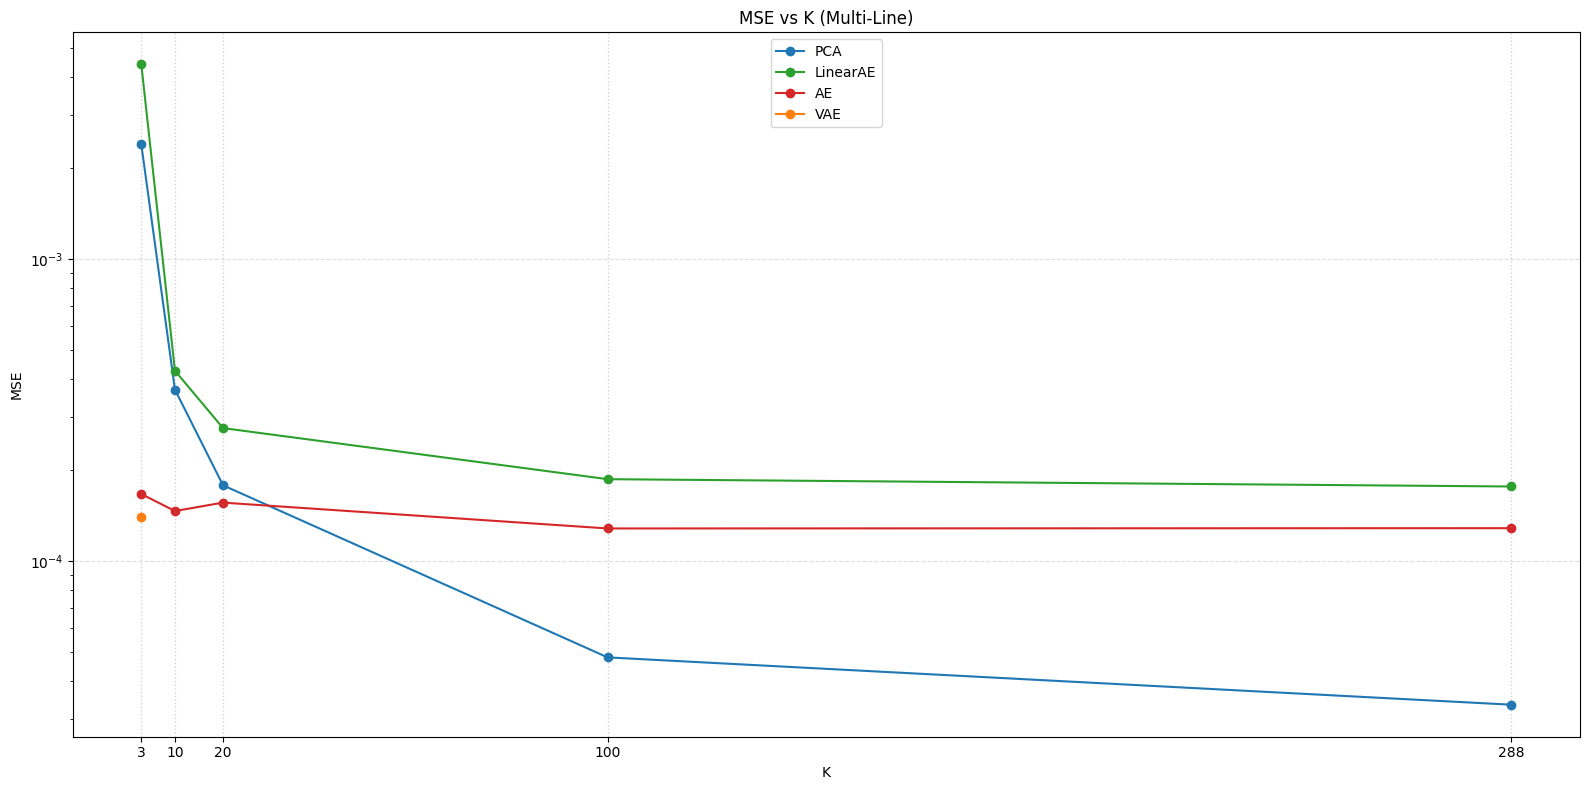

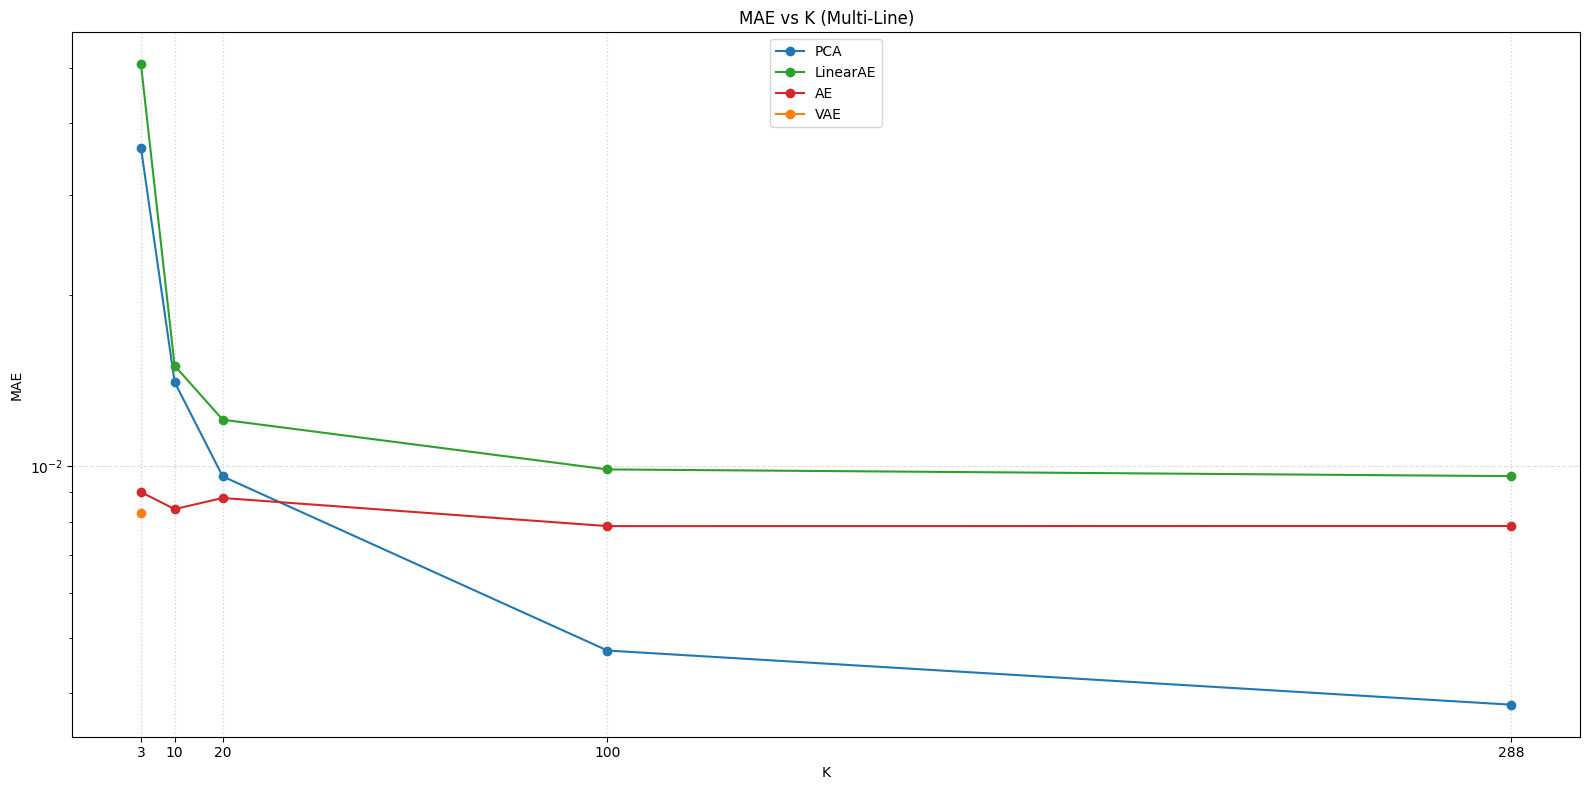

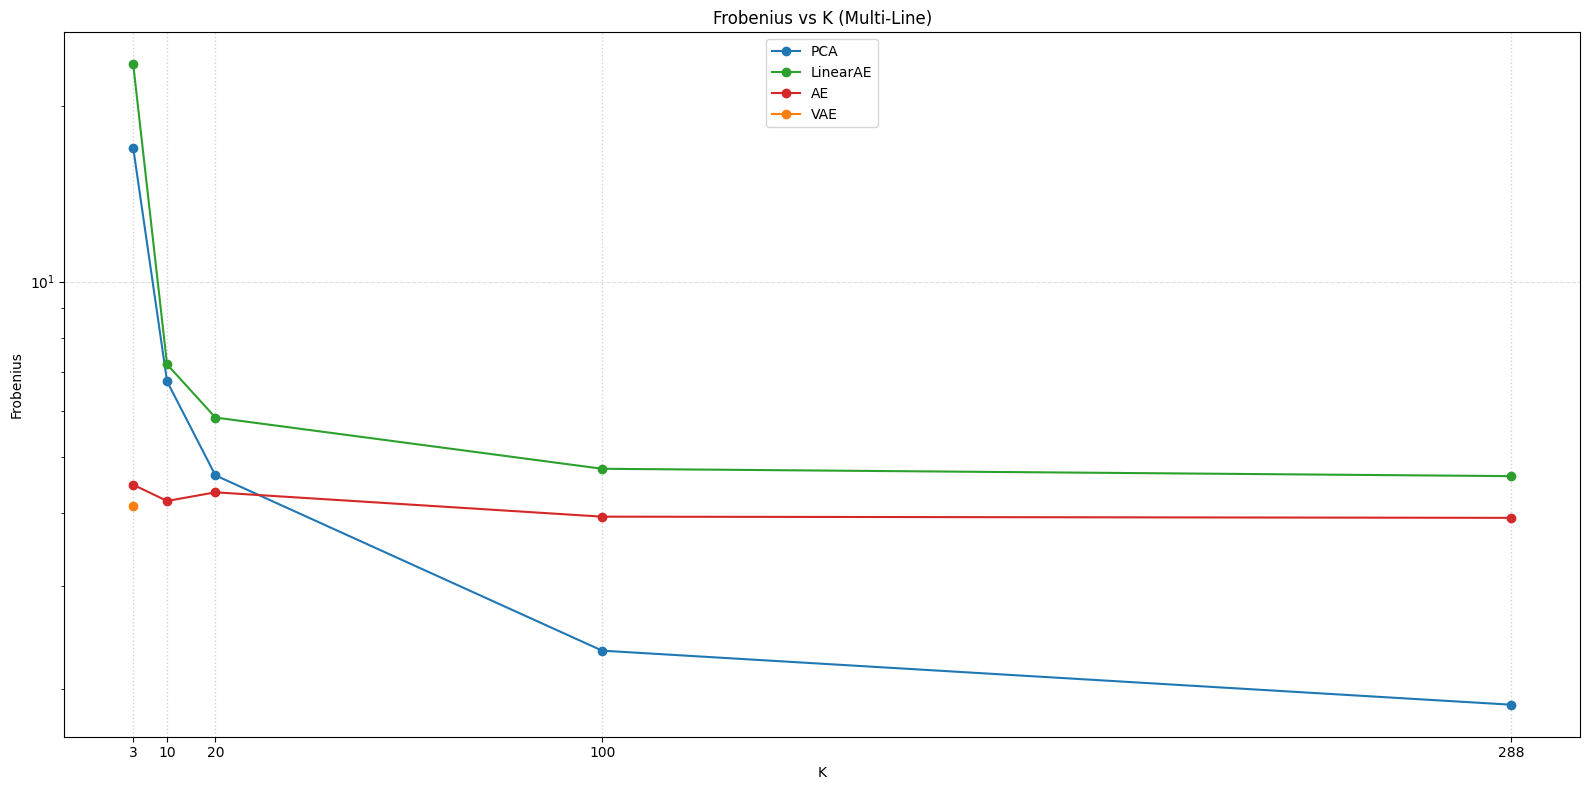

In [7]:
for metric in available_err_metrics:
    fig, ax = plt.subplots(figsize=(16, 8))
    all_x = []
    all_y = []
    for method in methods:
        subset = err_long[
            (err_long["metric"] == metric) & (err_long["method"] == method)
        ].sort_values("K")
        x_vals = subset["K"].to_numpy()
        y_vals = subset["error"].to_numpy()
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        ax.plot(
            x_vals,
            y_vals,
            marker="o",
            label=method_labels.get(method, method),
            color=method_colors.get(method),
        )

    ax.set_title(f"{metric} vs K (Multi-Line)")
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_yscale("log")
    if all_x:
        k_ticks = sorted(set(all_x))
        ax.set_xticks(k_ticks)
        for k_tick in k_ticks:
            ax.axvline(
                k_tick,
                linestyle=":",
                color="gray",
                alpha=0.35,
                linewidth=1,
            )
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plot_path = comparison_dir / f"err_{metric}_vs_k.png"
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()

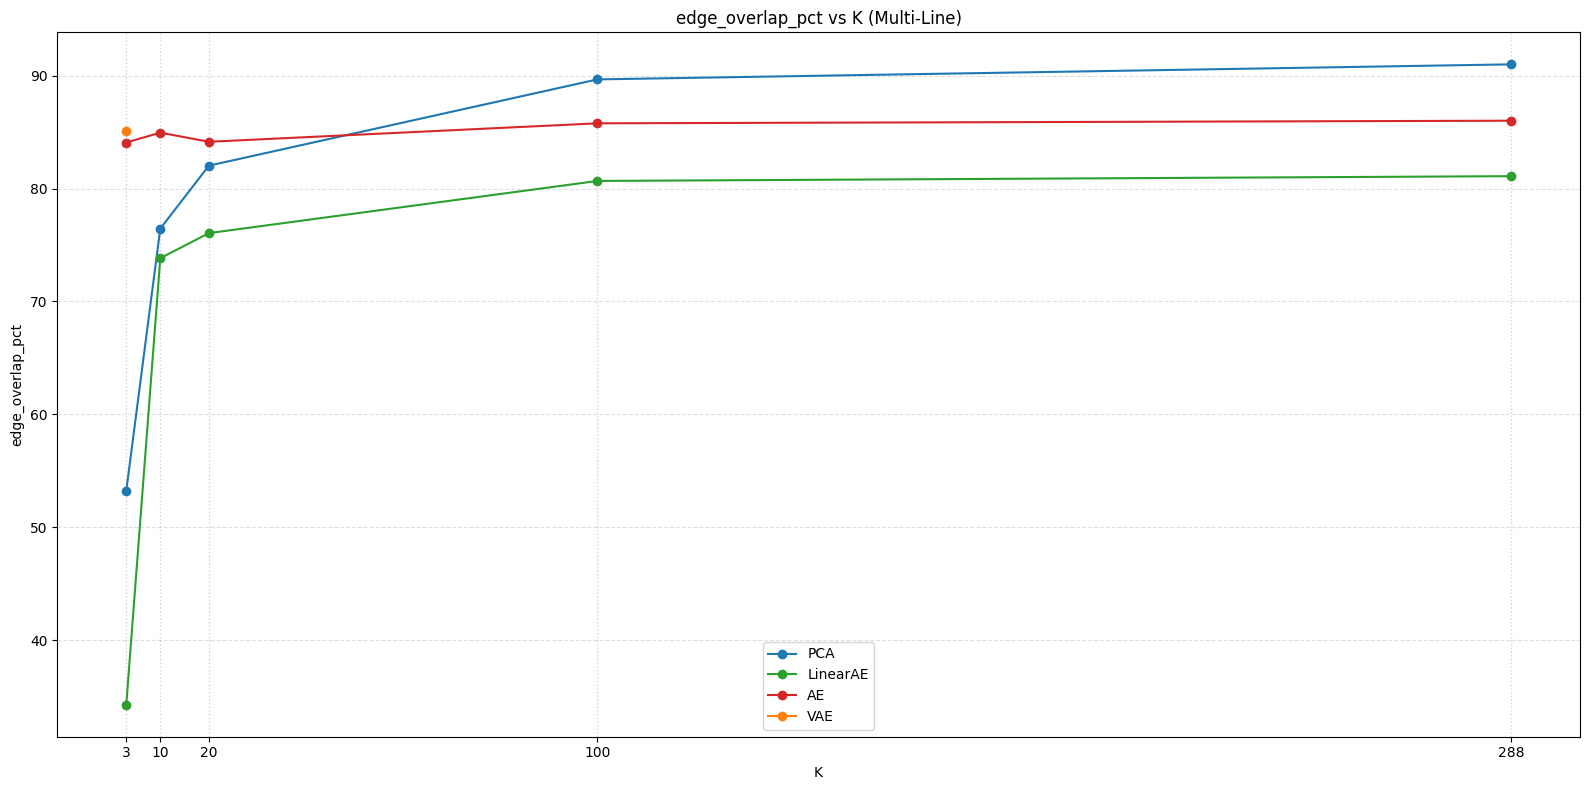

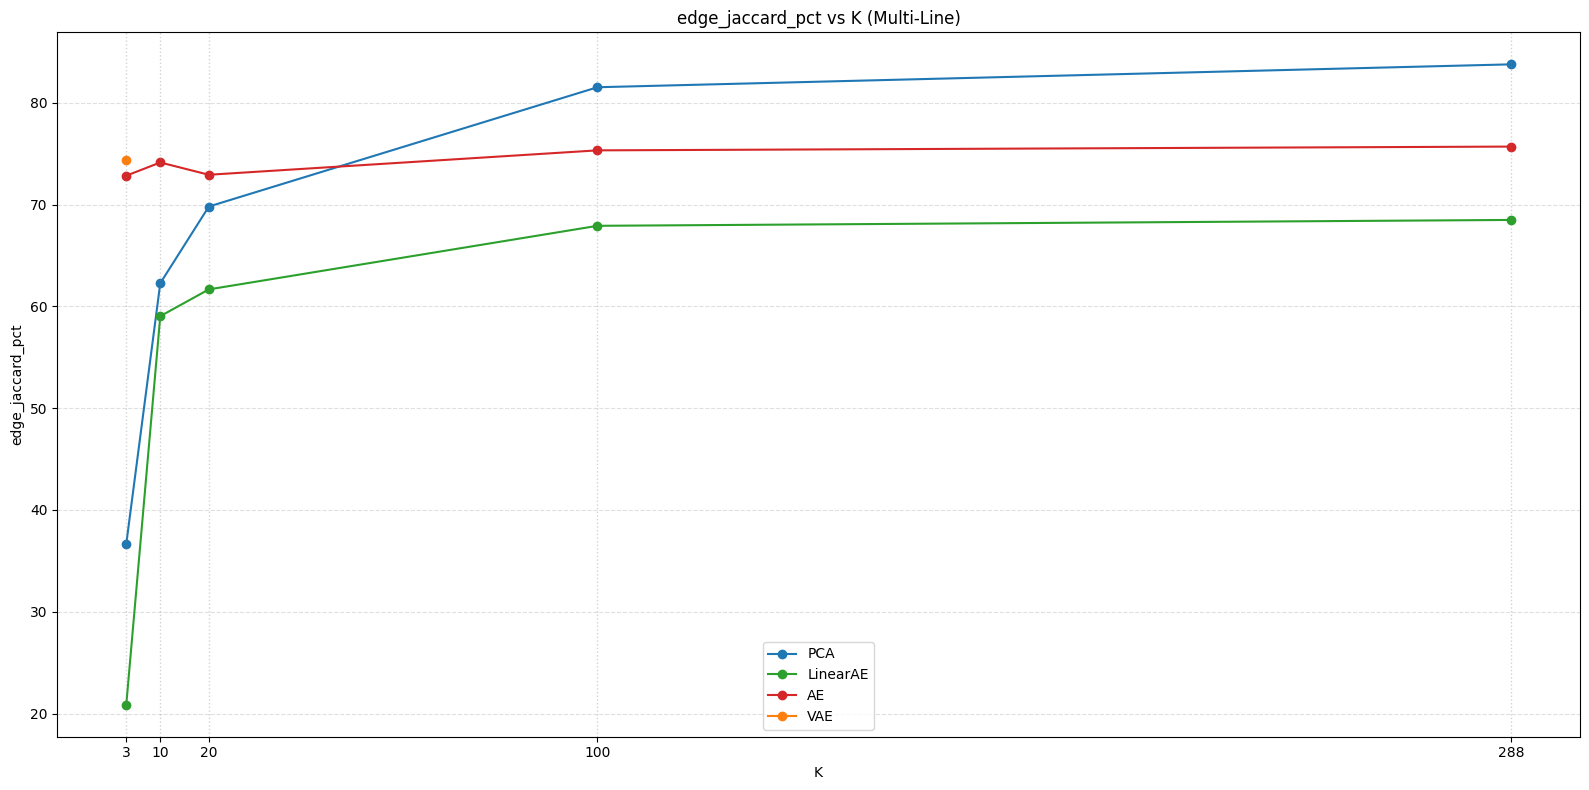

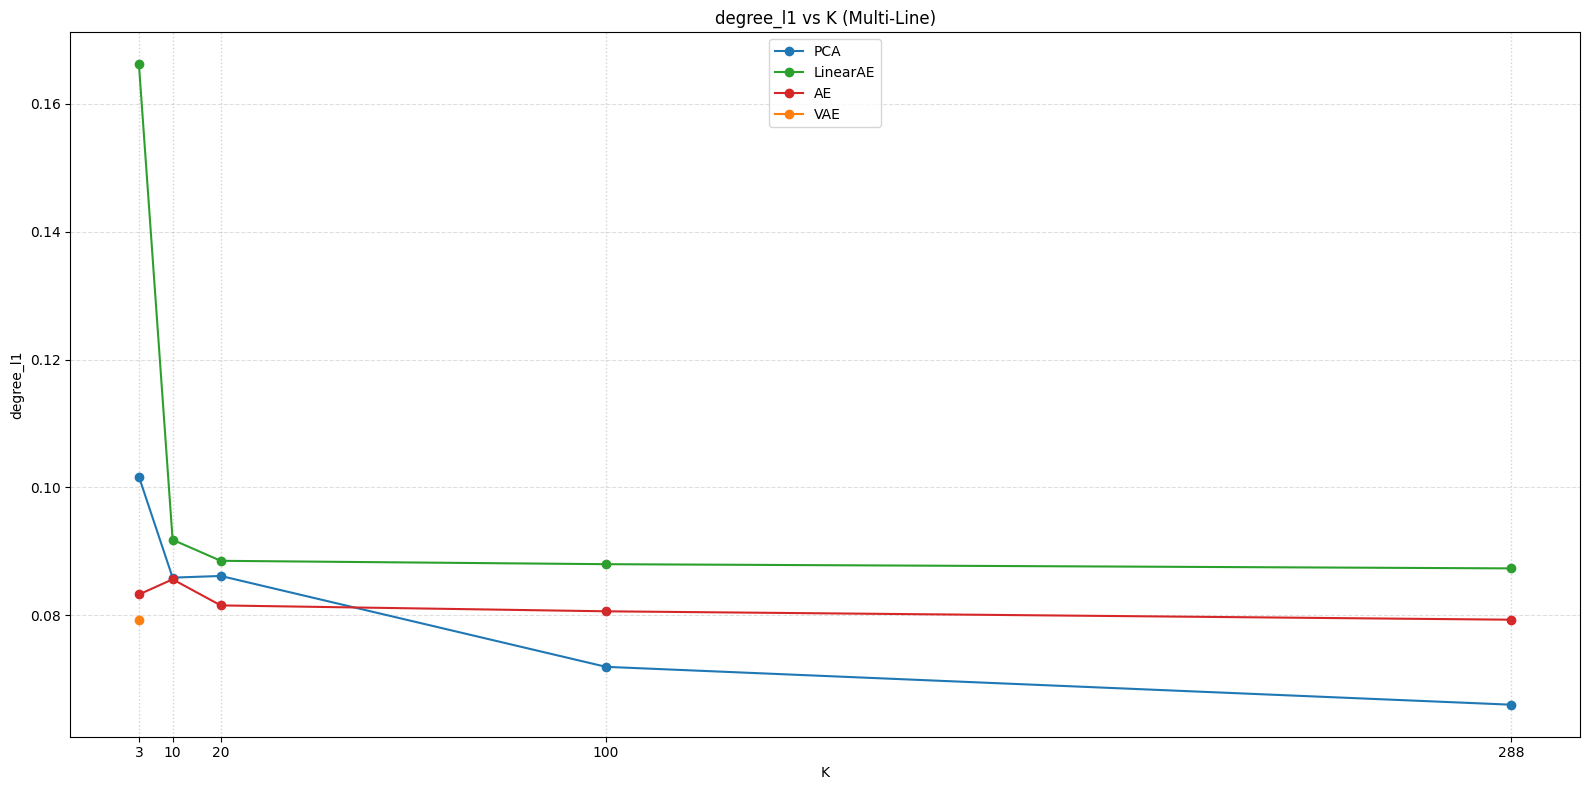

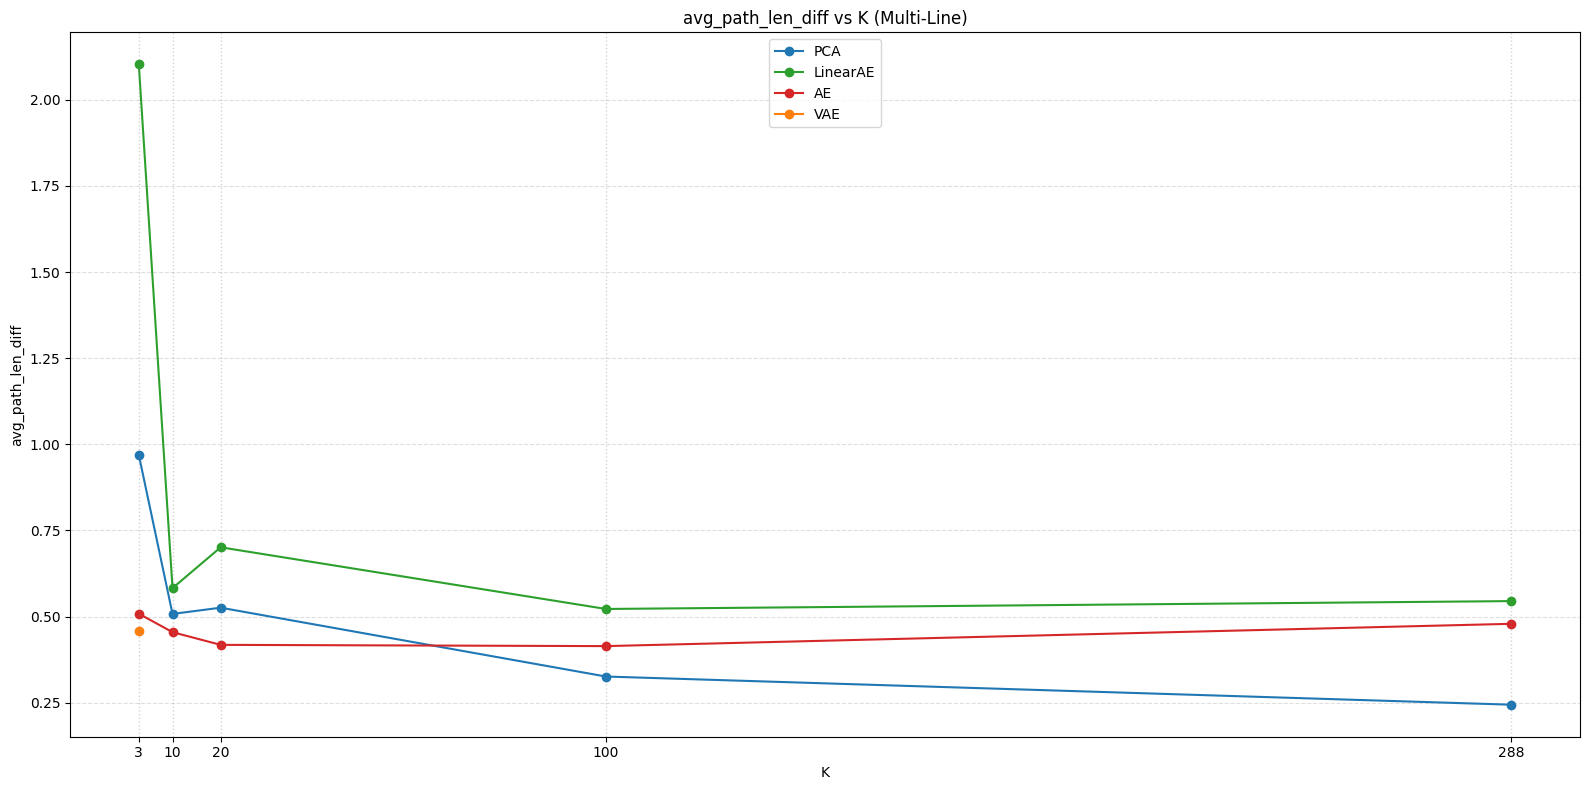

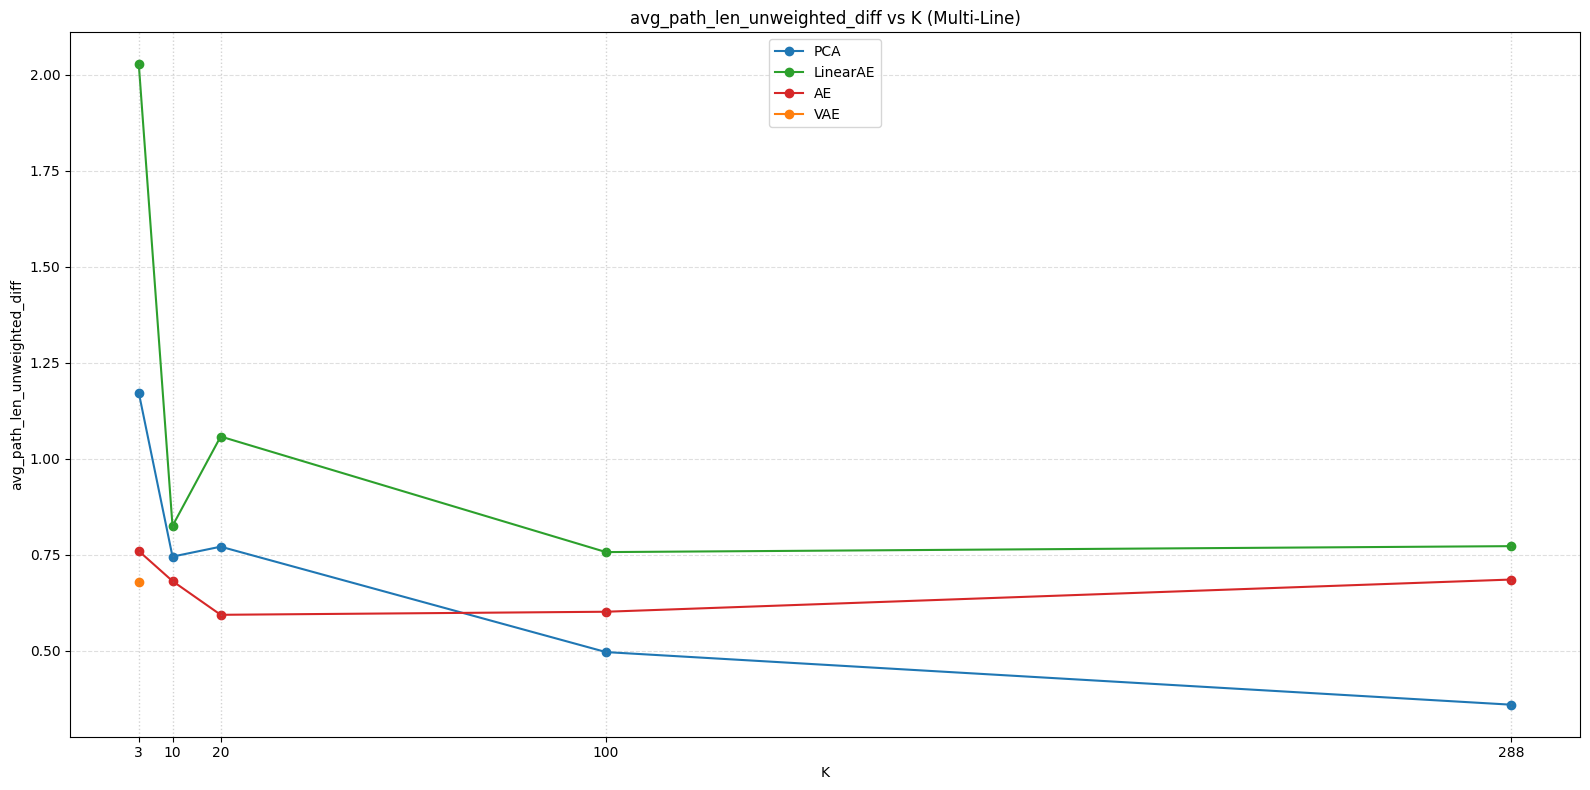

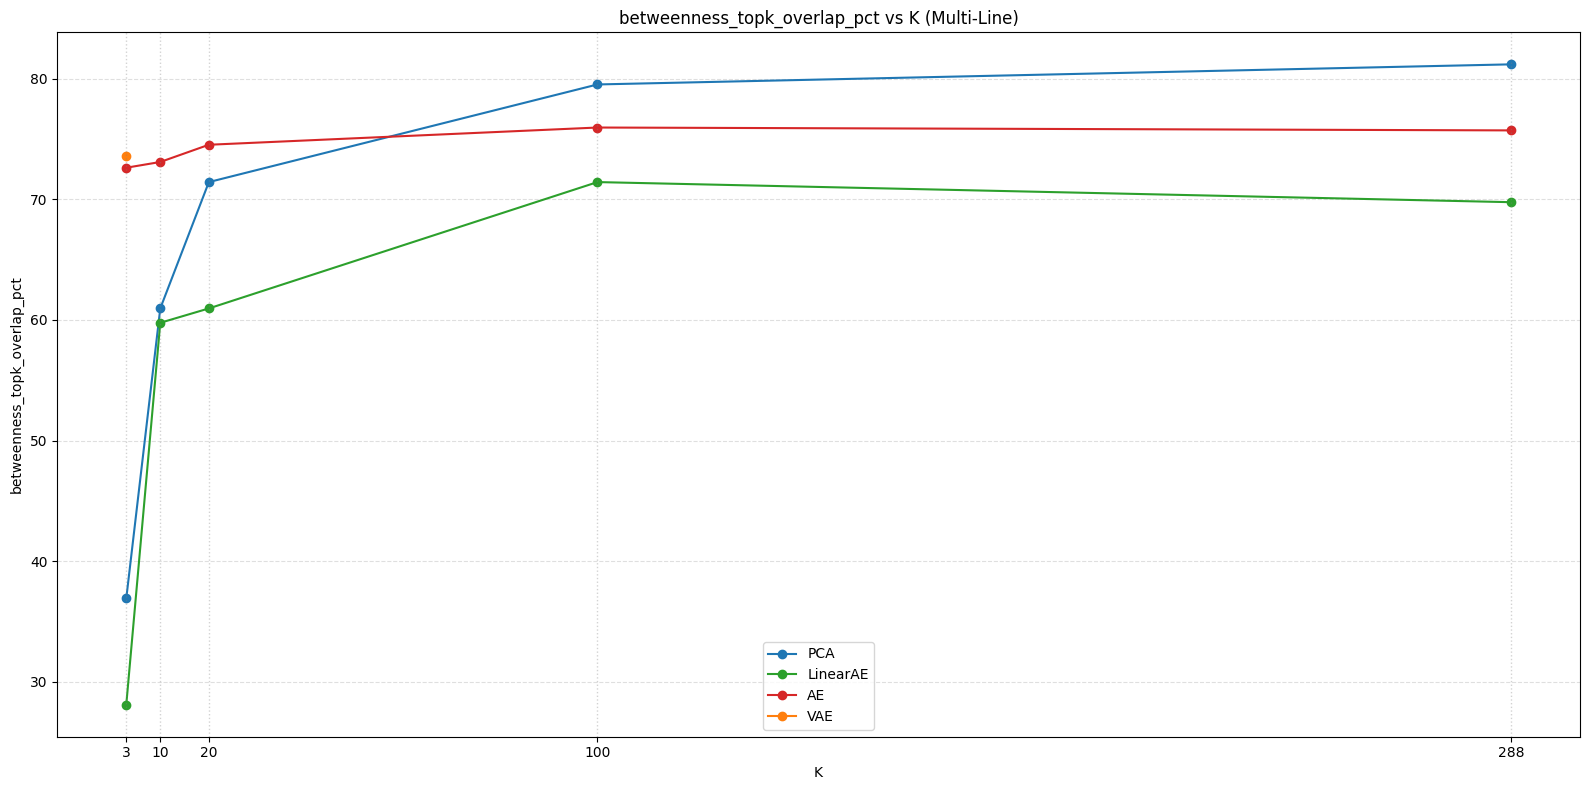

In [8]:
# MST K-based comparison plots
mst_by_model = mst_means.join(meta_df)
mst_by_model = mst_by_model.dropna(subset=["K", "method"]).copy()
mst_by_model["K"] = mst_by_model["K"].astype(int)

if mst_by_model.empty:
    raise ValueError("No valid MST models with parsed K were found.")

mst_long = mst_by_model.melt(
    id_vars=["method", "K"],
    value_vars=available_mst_metrics,
    var_name="metric",
    value_name="value",
)

mst_methods = [m for m in method_order if m in mst_long["method"].unique()]
if not mst_methods:
    mst_methods = sorted(mst_long["method"].unique())

mst_ks_sorted = sorted(mst_long["K"].unique())

for metric in available_mst_metrics:
    fig, ax = plt.subplots(figsize=(16, 8))
    all_x = []
    all_y = []
    for method in mst_methods:
        subset = mst_long[
            (mst_long["metric"] == metric) & (mst_long["method"] == method)
        ].sort_values("K")
        if subset.empty:
            continue
        x_vals = subset["K"].to_numpy()
        y_vals = subset["value"].to_numpy()
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        ax.plot(
            x_vals,
            y_vals,
            marker="o",
            label=method_labels.get(method, method),
            color=method_colors.get(method),
        )

    ax.set_title(f"{metric} vs K (Multi-Line)")
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    if all_x:
        k_ticks = sorted(set(all_x))
        ax.set_xticks(k_ticks)
        for k_tick in k_ticks:
            ax.axvline(
                k_tick,
                linestyle=":",
                color="gray",
                alpha=0.35,
                linewidth=1,
            )
    if all_y:
        y_min = min(all_y)
        y_max = max(all_y)
        if y_min > 0 and (y_max / y_min) >= 1000:
            ax.set_yscale("log")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plot_path = comparison_dir / f"mst_{metric}_vs_k.png"
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()